In [1]:
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt

### Low Resolution: Interpolation

In [2]:
# Open X
X = xr.open_dataset('/glade/derecho/scratch/skygale/Downscaling_Data/X_perfmodexp_interp.nc').X

# Get lat, lon
llat = X.lat.values
llon = X.lon.values % 360

# Clip to max thickness (remove spurious CESM1.3 artifacts)
is_ch0 = X.channel == X.channel.values[0]
X = xr.where(is_ch0, X.clip(max=6.0), X, keep_attrs=True)
X = X.transpose("ensemble", "time", "channel", "lat", "lon")

X.dims

('ensemble', 'time', 'channel', 'lat', 'lon')

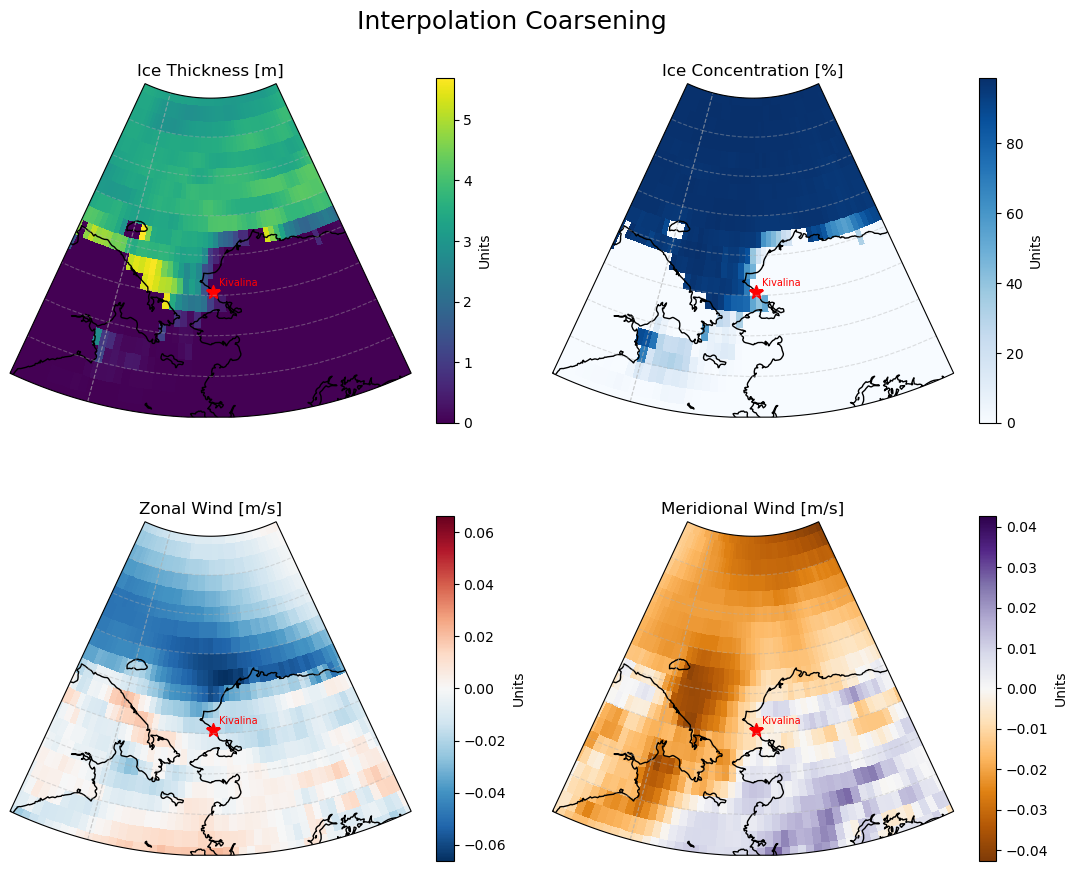

In [3]:
bbox = {"lon_min": -190, "lon_max": -140, "lat_min": 60, "lat_max": 80}
lon_min = bbox["lon_min"] % 360
lon_max = bbox["lon_max"] % 360

kivalina_lat = 67.7269
kivalina_lon_360 = -164.5333 % 360

central_lon = (bbox["lon_min"] + bbox["lon_max"]) / 2
proj = ccrs.NorthPolarStereo(central_longitude=central_lon)

channel_titles = ["Ice Thickness [m]", "Ice Concentration [%]", "Zonal Wind [m/s]", "Meridional Wind [m/s]"]
channel_cmaps = ["viridis", "Blues", "RdBu_r", "PuOr"]
diverging = [False, False, True, True]

n = 50
lons = np.concatenate([
    np.linspace(bbox["lon_min"], bbox["lon_max"], n),
    np.full(n, bbox["lon_max"]),
    np.linspace(bbox["lon_max"], bbox["lon_min"], n),
    np.full(n, bbox["lon_min"]),
])
lats = np.concatenate([
    np.full(n, bbox["lat_min"]),
    np.linspace(bbox["lat_min"], bbox["lat_max"], n),
    np.full(n, bbox["lat_max"]),
    np.linspace(bbox["lat_max"], bbox["lat_min"], n),
])
boundary_pts = proj.transform_points(ccrs.PlateCarree(), lons, lats)
boundary_path = mpath.Path(boundary_pts[:, :2])

fig, axes = plt.subplots(2, 2, figsize=(11, 10), subplot_kw={"projection": proj})

for ch, (ax, title, cmap, is_div) in enumerate(zip(axes.flat, channel_titles, channel_cmaps, diverging)):
    field = X[0, 100, ch]
    if is_div:
        vmax = float(np.abs(field).max())
        vmin = -vmax
    else:
        vmin, vmax = None, None
    cf = ax.pcolormesh(
        X.lon, X.lat, field,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading="auto",
    )
    ax.coastlines(resolution="50m")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.set_extent(
        [lon_min, lon_max, bbox["lat_min"], bbox["lat_max"]],
        crs=ccrs.PlateCarree(),
    )
    ax.set_boundary(boundary_path, transform=proj)
    ax.plot(kivalina_lon_360, kivalina_lat, marker="*", color="red", markersize=10, transform=ccrs.PlateCarree())
    ax.text(kivalina_lon_360 + 1, kivalina_lat + 0.35, "Kivalina", color="red", fontsize=7, transform=ccrs.PlateCarree())
    ax.gridlines(draw_labels=False, linestyle="--", alpha=0.4)
    ax.set_title(title, fontsize=12)
    plt.colorbar(cf, ax=ax, shrink=0.7, label="Units")

plt.suptitle('Interpolation Coarsening', fontsize=18, x=0.47, y=0.94)
plt.tight_layout()
plt.show()

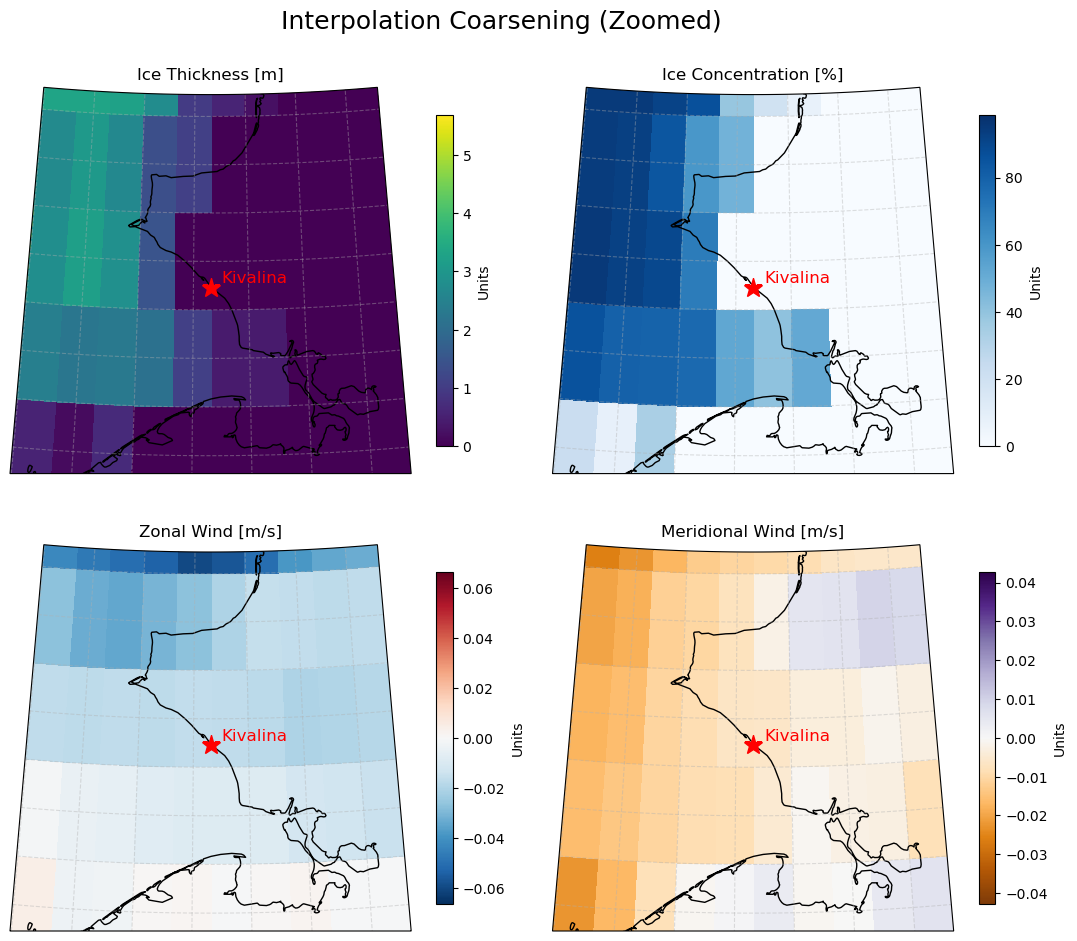

In [4]:
kivalina_lat = 67.7269
kivalina_lon = -164.5333          # plain -180/180 convention
kivalina_lon_360 = kivalina_lon % 360

# Tight box centered on Kivalina
bbox_zoom = {
    "lat_min": kivalina_lat - 2.0,
    "lat_max": kivalina_lat + 2.0,
    "lon_min": kivalina_lon - 5.0,
    "lon_max": kivalina_lon + 5.0,
}
lon_min_z = bbox_zoom["lon_min"] % 360
lon_max_z = bbox_zoom["lon_max"] % 360

central_lon = kivalina_lon   # center the projection right on Kivalina
proj = ccrs.NorthPolarStereo(central_longitude=central_lon)

channel_titles = ["Ice Thickness [m]", "Ice Concentration [%]", "Zonal Wind [m/s]", "Meridional Wind [m/s]"]
channel_cmaps = ["viridis", "Blues", "RdBu_r", "PuOr"]
diverging = [False, False, True, True]

# Clip boundary for the zoomed box
n = 50
lons = np.concatenate([
    np.linspace(bbox_zoom["lon_min"], bbox_zoom["lon_max"], n),
    np.full(n, bbox_zoom["lon_max"]),
    np.linspace(bbox_zoom["lon_max"], bbox_zoom["lon_min"], n),
    np.full(n, bbox_zoom["lon_min"]),
])
lats = np.concatenate([
    np.full(n, bbox_zoom["lat_min"]),
    np.linspace(bbox_zoom["lat_min"], bbox_zoom["lat_max"], n),
    np.full(n, bbox_zoom["lat_max"]),
    np.linspace(bbox_zoom["lat_max"], bbox_zoom["lat_min"], n),
])
boundary_pts = proj.transform_points(ccrs.PlateCarree(), lons, lats)
boundary_path = mpath.Path(boundary_pts[:, :2])

fig, axes = plt.subplots(2, 2, figsize=(11, 10), subplot_kw={"projection": proj})

for ch, (ax, title, cmap, is_div) in enumerate(zip(axes.flat, channel_titles, channel_cmaps, diverging)):
    field = X[0, 100, ch]
    if is_div:
        vmax = float(np.abs(field).max())
        vmin = -vmax
    else:
        vmin, vmax = None, None
    cf = ax.pcolormesh(
        X.lon, X.lat, field,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading="auto",
    )
    ax.coastlines(resolution="10m")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.set_extent(
        [lon_min_z, lon_max_z, bbox_zoom["lat_min"], bbox_zoom["lat_max"]],
        crs=ccrs.PlateCarree(),
    )
    ax.set_boundary(boundary_path, transform=proj)
    ax.plot(kivalina_lon_360, kivalina_lat, marker="*", color="red", markersize=14, transform=ccrs.PlateCarree())
    ax.text(kivalina_lon_360 + 0.3, kivalina_lat + 0.05, "Kivalina", color="red", fontsize=12, transform=ccrs.PlateCarree())
    ax.gridlines(draw_labels=False, linestyle="--", alpha=0.4)
    ax.set_title(title, fontsize=12)
    plt.colorbar(cf, ax=ax, shrink=0.7, label="Units")

plt.suptitle('Interpolation Coarsening (Zoomed)', fontsize=18, x=0.46, y=0.98)
plt.tight_layout()
plt.show()

### Low Resolution (Averaging)

In [5]:
# Open X
X = xr.open_dataset('/glade/derecho/scratch/skygale/Downscaling_Data/X_perfmodexp_avg.nc').X

# Get lat, lon
llat = X.lat.values
llon = X.lon.values % 360

# Clip to max thickness (remove spurious CESM1.3 artifacts)
is_ch0 = X.channel == X.channel.values[0]
X = xr.where(is_ch0, X.clip(max=6.0), X, keep_attrs=True)
X = X.transpose("ensemble", "time", "channel", "lat", "lon")

X.dims

('ensemble', 'time', 'channel', 'lat', 'lon')

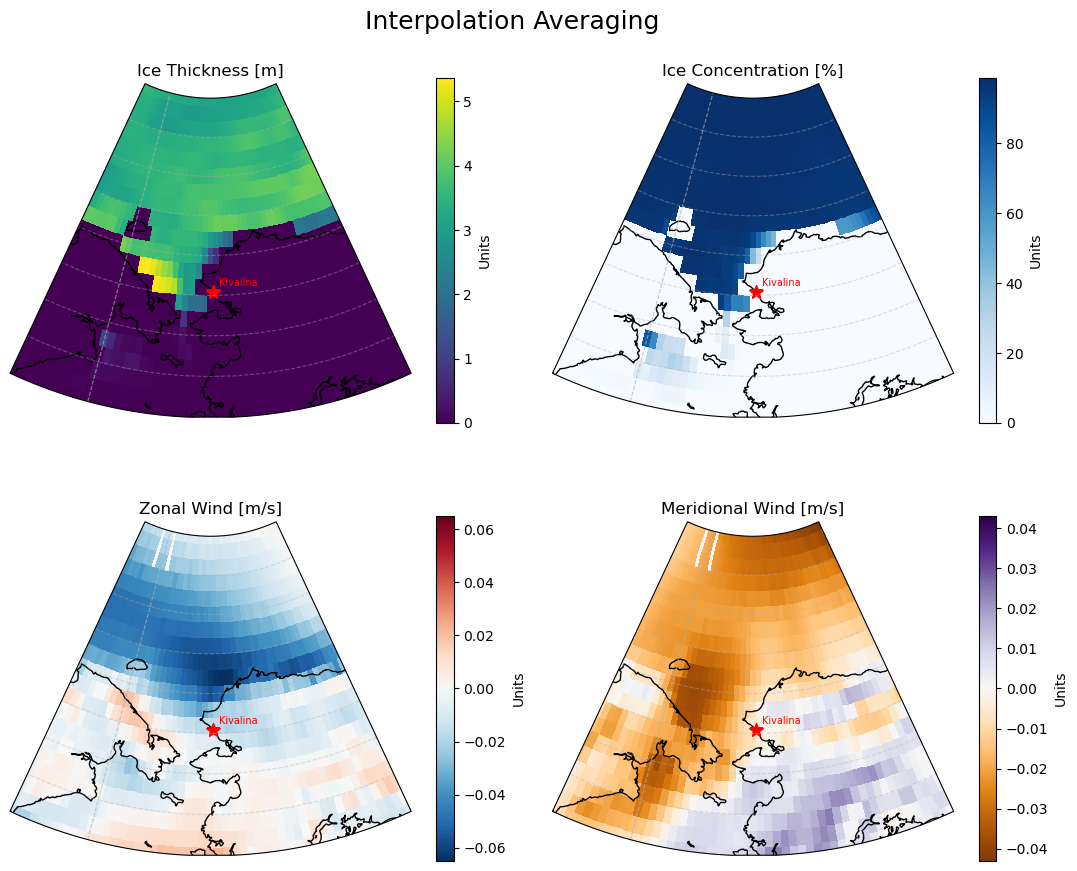

In [6]:
bbox = {"lon_min": -190, "lon_max": -140, "lat_min": 60, "lat_max": 80}
lon_min = bbox["lon_min"] % 360
lon_max = bbox["lon_max"] % 360

kivalina_lat = 67.7269
kivalina_lon_360 = -164.5333 % 360

central_lon = (bbox["lon_min"] + bbox["lon_max"]) / 2
proj = ccrs.NorthPolarStereo(central_longitude=central_lon)

channel_titles = ["Ice Thickness [m]", "Ice Concentration [%]", "Zonal Wind [m/s]", "Meridional Wind [m/s]"]
channel_cmaps = ["viridis", "Blues", "RdBu_r", "PuOr"]
diverging = [False, False, True, True]

n = 50
lons = np.concatenate([
    np.linspace(bbox["lon_min"], bbox["lon_max"], n),
    np.full(n, bbox["lon_max"]),
    np.linspace(bbox["lon_max"], bbox["lon_min"], n),
    np.full(n, bbox["lon_min"]),
])
lats = np.concatenate([
    np.full(n, bbox["lat_min"]),
    np.linspace(bbox["lat_min"], bbox["lat_max"], n),
    np.full(n, bbox["lat_max"]),
    np.linspace(bbox["lat_max"], bbox["lat_min"], n),
])
boundary_pts = proj.transform_points(ccrs.PlateCarree(), lons, lats)
boundary_path = mpath.Path(boundary_pts[:, :2])

fig, axes = plt.subplots(2, 2, figsize=(11, 10), subplot_kw={"projection": proj})

for ch, (ax, title, cmap, is_div) in enumerate(zip(axes.flat, channel_titles, channel_cmaps, diverging)):
    field = X[0, 100, ch]
    if is_div:
        vmax = float(np.abs(field).max())
        vmin = -vmax
    else:
        vmin, vmax = None, None
    cf = ax.pcolormesh(
        X.lon, X.lat, field,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading="auto",
    )
    ax.coastlines(resolution="50m")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.set_extent(
        [lon_min, lon_max, bbox["lat_min"], bbox["lat_max"]],
        crs=ccrs.PlateCarree(),
    )
    ax.set_boundary(boundary_path, transform=proj)
    ax.plot(kivalina_lon_360, kivalina_lat, marker="*", color="red", markersize=10, transform=ccrs.PlateCarree())
    ax.text(kivalina_lon_360 + 1, kivalina_lat + 0.35, "Kivalina", color="red", fontsize=7, transform=ccrs.PlateCarree())
    ax.gridlines(draw_labels=False, linestyle="--", alpha=0.4)
    ax.set_title(title, fontsize=12)
    plt.colorbar(cf, ax=ax, shrink=0.7, label="Units")

plt.suptitle('Interpolation Averaging', fontsize=18, x=0.47, y=0.94)
plt.tight_layout()
plt.show()

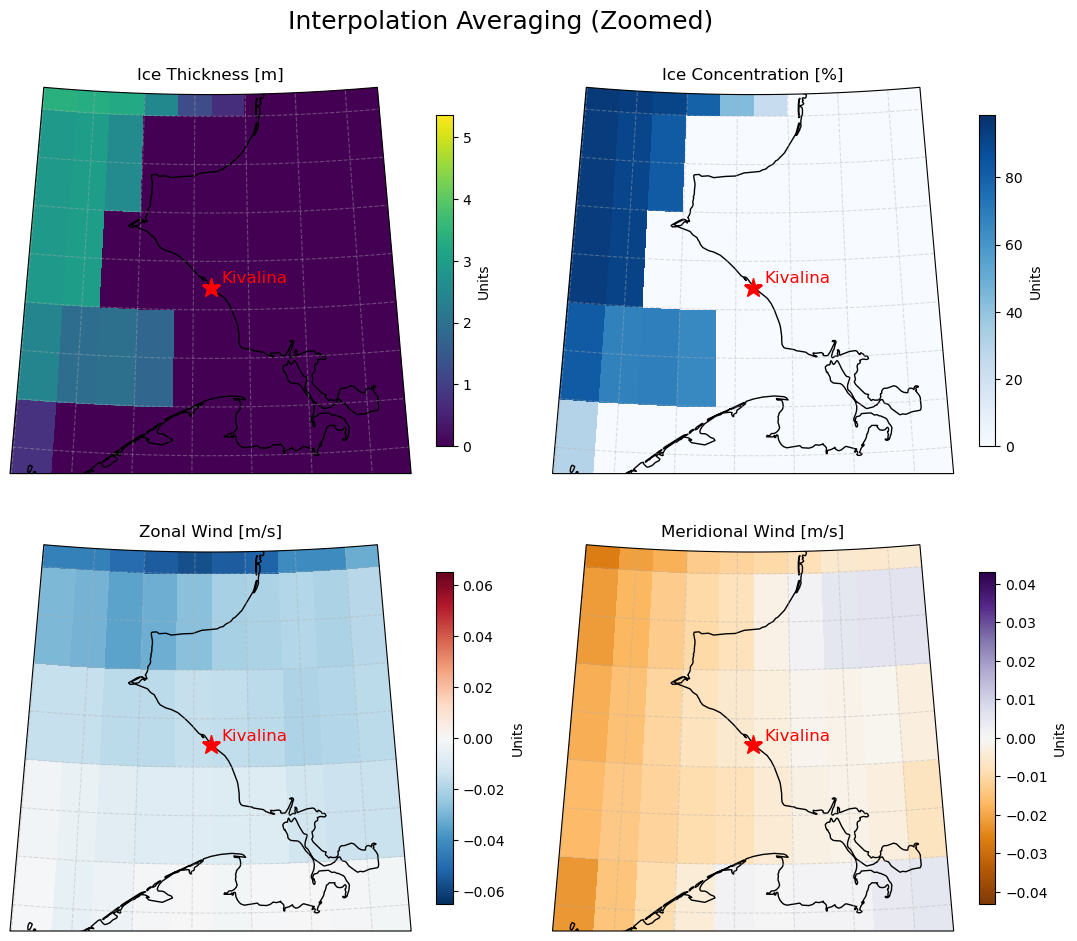

In [7]:
kivalina_lat = 67.7269
kivalina_lon = -164.5333          # plain -180/180 convention
kivalina_lon_360 = kivalina_lon % 360

# Tight box centered on Kivalina
bbox_zoom = {
    "lat_min": kivalina_lat - 2.0,
    "lat_max": kivalina_lat + 2.0,
    "lon_min": kivalina_lon - 5.0,
    "lon_max": kivalina_lon + 5.0,
}
lon_min_z = bbox_zoom["lon_min"] % 360
lon_max_z = bbox_zoom["lon_max"] % 360

central_lon = kivalina_lon   # center the projection right on Kivalina
proj = ccrs.NorthPolarStereo(central_longitude=central_lon)

channel_titles = ["Ice Thickness [m]", "Ice Concentration [%]", "Zonal Wind [m/s]", "Meridional Wind [m/s]"]
channel_cmaps = ["viridis", "Blues", "RdBu_r", "PuOr"]
diverging = [False, False, True, True]

# Clip boundary for the zoomed box
n = 50
lons = np.concatenate([
    np.linspace(bbox_zoom["lon_min"], bbox_zoom["lon_max"], n),
    np.full(n, bbox_zoom["lon_max"]),
    np.linspace(bbox_zoom["lon_max"], bbox_zoom["lon_min"], n),
    np.full(n, bbox_zoom["lon_min"]),
])
lats = np.concatenate([
    np.full(n, bbox_zoom["lat_min"]),
    np.linspace(bbox_zoom["lat_min"], bbox_zoom["lat_max"], n),
    np.full(n, bbox_zoom["lat_max"]),
    np.linspace(bbox_zoom["lat_max"], bbox_zoom["lat_min"], n),
])
boundary_pts = proj.transform_points(ccrs.PlateCarree(), lons, lats)
boundary_path = mpath.Path(boundary_pts[:, :2])

fig, axes = plt.subplots(2, 2, figsize=(11, 10), subplot_kw={"projection": proj})

for ch, (ax, title, cmap, is_div) in enumerate(zip(axes.flat, channel_titles, channel_cmaps, diverging)):
    field = X[0, 100, ch]
    if is_div:
        vmax = float(np.abs(field).max())
        vmin = -vmax
    else:
        vmin, vmax = None, None
    cf = ax.pcolormesh(
        X.lon, X.lat, field,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        shading="auto",
    )
    ax.coastlines(resolution="10m")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.set_extent(
        [lon_min_z, lon_max_z, bbox_zoom["lat_min"], bbox_zoom["lat_max"]],
        crs=ccrs.PlateCarree(),
    )
    ax.set_boundary(boundary_path, transform=proj)
    ax.plot(kivalina_lon_360, kivalina_lat, marker="*", color="red", markersize=14, transform=ccrs.PlateCarree())
    ax.text(kivalina_lon_360 + 0.3, kivalina_lat + 0.05, "Kivalina", color="red", fontsize=12, transform=ccrs.PlateCarree())
    ax.gridlines(draw_labels=False, linestyle="--", alpha=0.4)
    ax.set_title(title, fontsize=12)
    plt.colorbar(cf, ax=ax, shrink=0.7, label="Units")

plt.suptitle('Interpolation Averaging (Zoomed)', fontsize=18, x=0.46, y=0.98)
plt.tight_layout()
plt.show()

### High Resolution (SIT)

In [8]:
# Open Y
Y = xr.open_dataset('/glade/derecho/scratch/skygale/Downscaling_Data/Y_perfmodexp.nc').Y

# Clip to max thickness (remove spurious CESM1.3 artifacts)
Y = Y.clip(max=6.0)

Y.dims

('ensemble', 'time', 'channel', 'lat', 'lon')

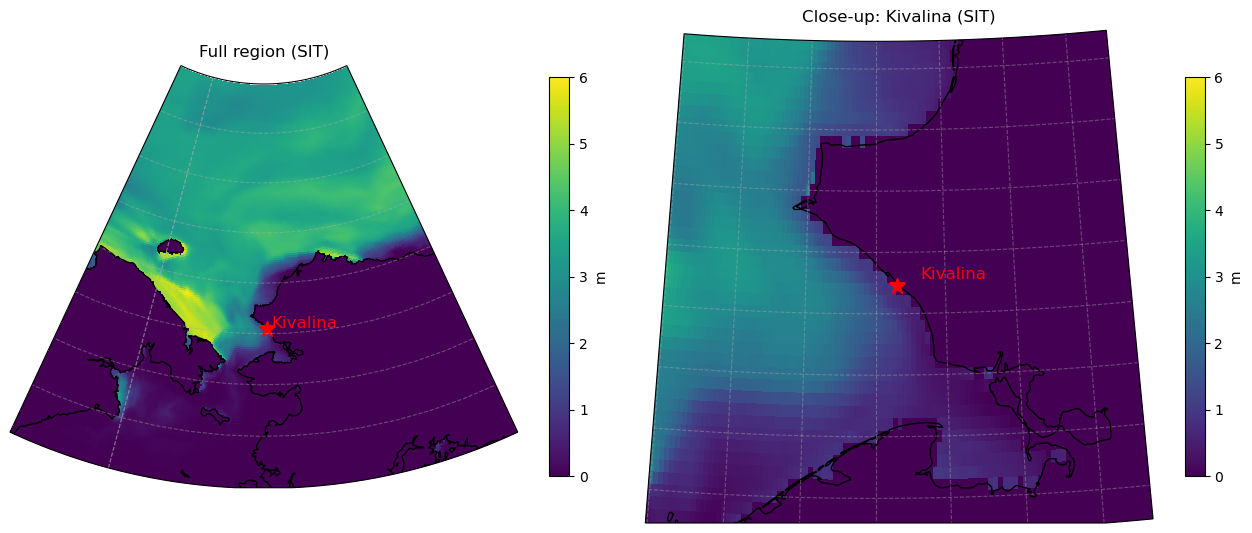

In [9]:
bbox = {"lon_min": -190, "lon_max": -140, "lat_min": 60, "lat_max": 80}
lon_min = bbox["lon_min"] % 360
lon_max = bbox["lon_max"] % 360

kivalina_lat = 67.7269
kivalina_lon = -164.5333
kivalina_lon_360 = kivalina_lon % 360

bbox_zoom = {
    "lat_min": kivalina_lat - 2.0,
    "lat_max": kivalina_lat + 2.0,
    "lon_min": kivalina_lon - 5.0,
    "lon_max": kivalina_lon + 5.0,
}
lon_min_z = bbox_zoom["lon_min"] % 360
lon_max_z = bbox_zoom["lon_max"] % 360

central_lon = (bbox["lon_min"] + bbox["lon_max"]) / 2  # -165
proj = ccrs.NorthPolarStereo(central_longitude=central_lon)


def make_boundary(box, n=50):
    lons = np.concatenate([
        np.linspace(box["lon_min"], box["lon_max"], n),
        np.full(n, box["lon_max"]),
        np.linspace(box["lon_max"], box["lon_min"], n),
        np.full(n, box["lon_min"]),
    ])
    lats = np.concatenate([
        np.full(n, box["lat_min"]),
        np.linspace(box["lat_min"], box["lat_max"], n),
        np.full(n, box["lat_max"]),
        np.linspace(box["lat_max"], box["lat_min"], n),
    ])
    pts = proj.transform_points(ccrs.PlateCarree(), lons, lats)
    return mpath.Path(pts[:, :2])


boundary_full = make_boundary(bbox)
boundary_zoom = make_boundary(bbox_zoom)

field = Y[0, 100, 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 6), subplot_kw={"projection": proj})

panel_specs = [
    (axes[0], "Full region (SIT)", bbox, lon_min, lon_max, boundary_full, "50m"),
    (axes[1], "Close-up: Kivalina (SIT)", bbox_zoom, lon_min_z, lon_max_z, boundary_zoom, "10m"),
]

for ax, title, box, lo_min, lo_max, boundary, coast_res in panel_specs:
    cf = ax.pcolormesh(
        Y.lon, Y.lat, field,
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        shading="auto",
    )
    ax.coastlines(resolution=coast_res)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.set_extent([lo_min, lo_max, box["lat_min"], box["lat_max"]], crs=ccrs.PlateCarree())
    ax.set_boundary(boundary, transform=proj)
    ax.plot(kivalina_lon_360, kivalina_lat, marker="*", color="red", markersize=12, transform=ccrs.PlateCarree())
    ax.text(kivalina_lon_360 + 0.5, kivalina_lat + 0.05, "Kivalina", color="red", fontsize=12, transform=ccrs.PlateCarree())
    ax.gridlines(draw_labels=False, linestyle="--", alpha=0.4)
    ax.set_title(title, fontsize=12)
    plt.colorbar(cf, ax=ax, shrink=0.7, label="m")

plt.tight_layout()
plt.show()

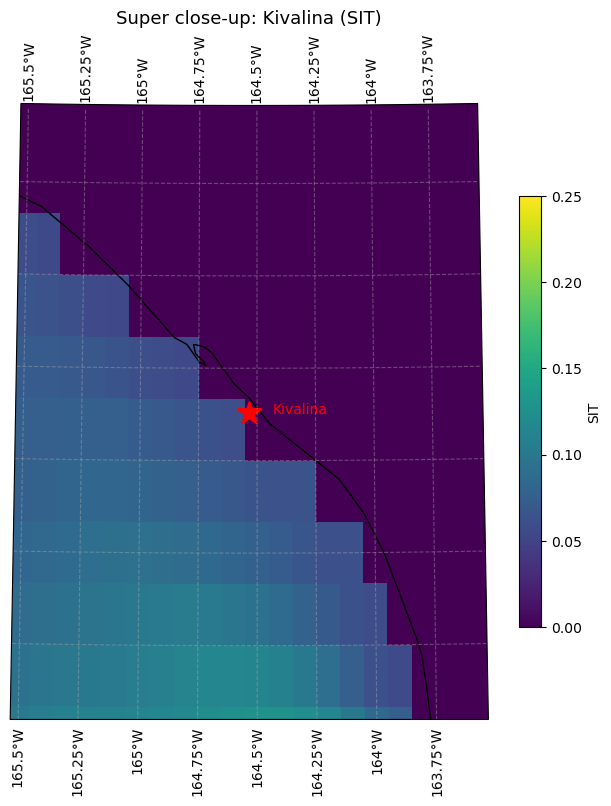

In [10]:
kivalina_lat = 67.7269
kivalina_lon = -164.5333
kivalina_lon_360 = kivalina_lon % 360

bbox_superzoom = {
    "lat_min": kivalina_lat - 0.5,
    "lat_max": kivalina_lat + 0.5,
    "lon_min": kivalina_lon - 1.0,
    "lon_max": kivalina_lon + 1.0,
}
lon_min_sz = bbox_superzoom["lon_min"] % 360
lon_max_sz = bbox_superzoom["lon_max"] % 360

proj = ccrs.NorthPolarStereo(central_longitude=kivalina_lon)

n = 50
lons = np.concatenate([
    np.linspace(bbox_superzoom["lon_min"], bbox_superzoom["lon_max"], n),
    np.full(n, bbox_superzoom["lon_max"]),
    np.linspace(bbox_superzoom["lon_max"], bbox_superzoom["lon_min"], n),
    np.full(n, bbox_superzoom["lon_min"]),
])
lats = np.concatenate([
    np.full(n, bbox_superzoom["lat_min"]),
    np.linspace(bbox_superzoom["lat_min"], bbox_superzoom["lat_max"], n),
    np.full(n, bbox_superzoom["lat_max"]),
    np.linspace(bbox_superzoom["lat_max"], bbox_superzoom["lat_min"], n),
])
boundary_pts = proj.transform_points(ccrs.PlateCarree(), lons, lats)
boundary_path = mpath.Path(boundary_pts[:, :2])

field = Y[-1, -1, 0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": proj})
cf = ax.pcolormesh(Y.lon, Y.lat, field, transform=ccrs.PlateCarree(), cmap="viridis", vmin=0, vmax=0.25, shading="auto")
ax.coastlines(resolution="10m")
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.set_extent([lon_min_sz, lon_max_sz, bbox_superzoom["lat_min"], bbox_superzoom["lat_max"]], crs=ccrs.PlateCarree())
ax.set_boundary(boundary_path, transform=proj)
ax.plot(kivalina_lon_360, kivalina_lat, marker="*", color="red", markersize=18, transform=ccrs.PlateCarree())
ax.text(kivalina_lon_360 + 0.1, kivalina_lat, "Kivalina", color="red", fontsize=10, transform=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.4)
ax.set_title("Super close-up: Kivalina (SIT)", fontsize=13)
plt.colorbar(cf, ax=ax, shrink=0.7, label="SIT")
plt.show()

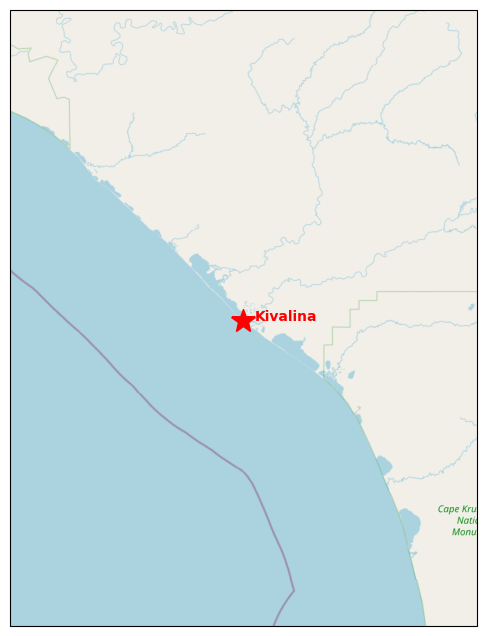

In [11]:
kivalina_lat = 67.7269
kivalina_lon = -164.5333

tiler = cimgt.OSM()  # OpenStreetMap basemap tiles

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": tiler.crs})

extent = [kivalina_lon - 1.0, kivalina_lon + 1.0, kivalina_lat - 0.5, kivalina_lat + 0.5]
ax.set_extent(extent, crs=ccrs.PlateCarree())
ax.add_image(tiler, 9)  # zoom level -- higher = more detail, slower to fetch

ax.plot(kivalina_lon, kivalina_lat, marker="*", color="red", markersize=18, transform=ccrs.PlateCarree())
ax.text(kivalina_lon + 0.05, kivalina_lat, "Kivalina", color="red", fontsize=10, fontweight="bold",
        transform=ccrs.PlateCarree())

plt.show()